In [1]:
 import os, time, random, base64, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.random_projection import SparseRandomProjection
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128  |  CUDA: True
GPU     : Tesla T4


In [2]:
pv_color_candidates, segmented_candidates, pd_candidates = [], [], []

for root, dirs, _ in os.walk("/kaggle/input"):
    for d in dirs:
        if d == "Corn_(maize)___healthy":
            full = Path(root) / d
            if full.parent.name == "color":
                pv_color_candidates.append(full)
            elif full.parent.name == "segmented":
                segmented_candidates.append(full)
        elif d == "Corn_rust_leaf":
            pd_candidates.append(Path(root) / d)

assert pv_color_candidates, "PlantVillage color healthy not found"
assert segmented_candidates, "PlantVillage segmented healthy not found"
assert pd_candidates, "PlantDoc root not found"

PV_ROOT  = pv_color_candidates[0].parent
SEG_ROOT = segmented_candidates[0].parent
PD_ROOT  = next(iter({c.parent.parent for c in pd_candidates}))

print(f"PV color (training+test)   : {PV_ROOT}")
print(f"PV segmented (NB5 stimulus): {SEG_ROOT}")
print(f"PlantDoc (cross-domain+bg) : {PD_ROOT}")

PV color (training+test)   : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
PV segmented (NB5 stimulus): /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
PlantDoc (cross-domain+bg) : /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def list_imgs(folder):
    return sorted(str(p) for p in folder.iterdir()
                  if p.suffix.lower() in IMG_EXTS)

PV_CLASSES = {
    "healthy":         "Corn_(maize)___healthy",
    "common_rust":     "Corn_(maize)___Common_rust_",
    "cercospora":      "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "northern_blight": "Corn_(maize)___Northern_Leaf_Blight",
}
PD_CLASSES = {
    "common_rust":     "Corn_rust_leaf",
    "northern_blight": "Corn_leaf_blight",
    "cercospora":      "Corn_Gray_leaf_spot",
}

# === Training splits (same seed 42 as NB1/NB2 for reproducibility) ===
random.seed(42)
healthy_color = list_imgs(PV_ROOT / PV_CLASSES["healthy"])
random.shuffle(healthy_color)
n = len(healthy_color)
n_train, n_val = int(n * 0.80), int(n * 0.10)
cae_train_paths = healthy_color[:n_train]
cae_val_paths   = healthy_color[n_train : n_train + n_val]
healthy_test    = healthy_color[n_train + n_val :]

# === In-domain + cross-domain test manifest ===
rows = []
for p in healthy_test:
    rows.append({"filepath": p, "class": "healthy", "domain": "plantvillage", "label": 0})

for cls, folder in PV_CLASSES.items():
    if cls == "healthy": continue
    for p in list_imgs(PV_ROOT / folder):
        rows.append({"filepath": p, "class": cls, "domain": "plantvillage", "label": 1})

for cls, folder in PD_CLASSES.items():
    for split in ("train", "test"):
        d = PD_ROOT / split / folder
        if d.exists():
            for p in list_imgs(d):
                rows.append({"filepath": p, "class": cls, "domain": "plantdoc", "label": 1})

test_df = pd.DataFrame(rows)

# === NB5 stimulus + background pools (different seed; don't bias to training) ===
random.seed(123)
segmented_all  = list_imgs(SEG_ROOT / PV_CLASSES["healthy"])
stimulus_paths = random.sample(segmented_all, 100)

pd_corn = []
for split in ("train", "test"):
    for folder in PD_CLASSES.values():
        d = PD_ROOT / split / folder
        if d.exists():
            pd_corn.extend(list_imgs(d))

pd_other = []
for split in ("train", "test"):
    split_dir = PD_ROOT / split
    if split_dir.exists():
        for crop_folder in split_dir.iterdir():
            if crop_folder.is_dir() and "corn" not in crop_folder.name.lower():
                pd_other.extend(list_imgs(crop_folder))

# Pre-sample one background per leaf (reproducible)
random.seed(42)
bg_pool_cond3 = random.sample(pd_other, 100)
bg_pool_cond4 = random.sample(pd_corn,  100)

# === Summary ===
print(f"=== Training ===")
print(f"  CAE/PatchCore/PaDiM train  : {len(cae_train_paths)} images")
print(f"  CAE val                    : {len(cae_val_paths)} images\n")

print(f"=== Test manifest ===")
print(test_df.groupby(["domain", "class"]).size().unstack(fill_value=0))
print(f"  Total test images          : {len(test_df)}\n")

print(f"=== NB5 controlled experiment ===")
print(f"  Stimulus leaves (segmented): {len(stimulus_paths)}")
print(f"  BG pool cond 3 (PD non-corn): {len(pd_other)}")
print(f"  BG pool cond 4 (PD corn-disease): {len(pd_corn)}")
print(f"  Sampled bgs per condition   : 100 (one per leaf)\n")

# Sanity check: same splits as NB1/NB2/NB4
assert len(cae_train_paths) == 929
assert len(cae_val_paths)   == 116
assert (test_df["split"] if "split" in test_df.columns else test_df).shape[0] == 3185
print("All splits match canonical (929 train, 116 val, 3185 test)")

=== Training ===
  CAE/PatchCore/PaDiM train  : 929 images
  CAE val                    : 116 images

=== Test manifest ===
class         cercospora  common_rust  healthy  northern_blight
domain                                                         
plantdoc              67          117        0              194
plantvillage         513         1192      117              985
  Total test images          : 3185

=== NB5 controlled experiment ===
  Stimulus leaves (segmented): 100
  BG pool cond 3 (PD non-corn): 2544
  BG pool cond 4 (PD corn-disease): 378
  Sampled bgs per condition   : 100 (one per leaf)

All splits match canonical (929 train, 116 val, 3185 test)


In [10]:
class SimpleImageDataset(torch.utils.data.Dataset):
    """Path-only dataset, used during CAE/PatchCore/PaDiM training."""
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img


class MaizeDataset(torch.utils.data.Dataset):
    """Image + metadata. Used at evaluation time for in-domain + cross-domain test."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return {
            "image": img,
            "label": int(row["label"]),
            "class": row["class"],
            "domain": row["domain"],
            "filepath": row["filepath"],
        }

In [11]:
CAE_IMG_SIZE = 128
BATCH_SIZE = 32

cae_transform = transforms.Compose([
    transforms.Resize((CAE_IMG_SIZE, CAE_IMG_SIZE)),
    transforms.ToTensor(),
])

cae_train_ds = SimpleImageDataset(cae_train_paths, transform=cae_transform)
cae_val_ds   = SimpleImageDataset(cae_val_paths,   transform=cae_transform)
cae_test_ds  = MaizeDataset(test_df, transform=cae_transform)

cae_train_loader = torch.utils.data.DataLoader(cae_train_ds, batch_size=BATCH_SIZE,
                                               shuffle=True, num_workers=2,
                                               pin_memory=True, drop_last=True)
cae_val_loader   = torch.utils.data.DataLoader(cae_val_ds, batch_size=BATCH_SIZE,
                                               shuffle=False, num_workers=2,
                                               pin_memory=True)
cae_test_loader  = torch.utils.data.DataLoader(cae_test_ds, batch_size=BATCH_SIZE,
                                               shuffle=False, num_workers=0,
                                               pin_memory=True)

batch = next(iter(cae_train_loader))
print(f"CAE train batch: {tuple(batch.shape)}, range [{batch.min():.3f}, {batch.max():.3f}]")

CAE train batch: (32, 3, 128, 128), range [0.012, 1.000]


In [12]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            self._enc(3,   32), self._enc(32,  64),
            self._enc(64, 128), self._enc(128, 256),
        )
        self.decoder = nn.Sequential(
            self._dec(256, 128), self._dec(128, 64), self._dec(64, 32),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _enc(c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, stride=2, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    @staticmethod
    def _dec(c_in, c_out):
        return nn.Sequential(
            nn.ConvTranspose2d(c_in, c_out, 4, stride=2, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


cae_model = ConvAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(cae_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
criterion = nn.MSELoss()

CAE_EPOCHS, PATIENCE = 50, 10
CAE_CKPT = Path("/kaggle/working/cae_best.pt")
best_val, no_improve = float("inf"), 0

def run_epoch(loader, train):
    cae_model.train() if train else cae_model.eval()
    total, n = 0.0, 0
    for x in loader:
        x = x.to(DEVICE, non_blocking=True)
        if train: optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            recon = cae_model(x)
            loss = criterion(recon, x)
        if train:
            loss.backward(); optimizer.step()
        total += loss.item() * x.size(0); n += x.size(0)
    return total / n

print(f"Training CAE on {DEVICE}...\n")
t0 = time.time()
for epoch in range(1, CAE_EPOCHS + 1):
    e0 = time.time()
    tr = run_epoch(cae_train_loader, True)
    vl = run_epoch(cae_val_loader,   False)
    scheduler.step(vl)
    if vl < best_val:
        best_val = vl
        torch.save({"model_state_dict": cae_model.state_dict(), "epoch": epoch}, CAE_CKPT)
        no_improve = 0; flag = " <- best"
    else:
        no_improve += 1; flag = ""
    print(f"Epoch {epoch:>2}/{CAE_EPOCHS}  train={tr:.5f}  val={vl:.5f}  "
          f"lr={optimizer.param_groups[0]['lr']:.1e}  ({time.time()-e0:.1f}s){flag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}. Best val: {best_val:.5f}")
        break

ckpt = torch.load(CAE_CKPT, map_location=DEVICE)
cae_model.load_state_dict(ckpt["model_state_dict"])
cae_model.eval()
print(f"\nCAE done in {(time.time()-t0)/60:.1f} min. Best val {best_val:.5f} at epoch {ckpt['epoch']}.")

Training CAE on cuda...

Epoch  1/50  train=0.02152  val=0.01538  lr=1.0e-03  (5.4s) <- best
Epoch  2/50  train=0.00735  val=0.00628  lr=1.0e-03  (1.5s) <- best
Epoch  3/50  train=0.00541  val=0.00470  lr=1.0e-03  (1.6s) <- best
Epoch  4/50  train=0.00488  val=0.00405  lr=1.0e-03  (1.5s) <- best
Epoch  5/50  train=0.00449  val=0.00480  lr=1.0e-03  (1.5s)
Epoch  6/50  train=0.00380  val=0.00371  lr=1.0e-03  (1.5s) <- best
Epoch  7/50  train=0.00335  val=0.00294  lr=1.0e-03  (1.5s) <- best
Epoch  8/50  train=0.00300  val=0.00389  lr=1.0e-03  (1.5s)
Epoch  9/50  train=0.00280  val=0.00255  lr=1.0e-03  (1.5s) <- best
Epoch 10/50  train=0.00246  val=0.00237  lr=1.0e-03  (1.6s) <- best
Epoch 11/50  train=0.00239  val=0.00228  lr=1.0e-03  (1.5s) <- best
Epoch 12/50  train=0.00210  val=0.00172  lr=1.0e-03  (1.5s) <- best
Epoch 13/50  train=0.00209  val=0.00162  lr=1.0e-03  (1.5s) <- best
Epoch 14/50  train=0.00188  val=0.00166  lr=1.0e-03  (1.5s)
Epoch 15/50  train=0.00215  val=0.00176  lr=1.0

In [13]:
print(f"CAE inference on {len(test_df)} test images...")
t0 = time.time()
cae_scores_list, cae_labels_list, cae_classes_list, cae_domains_list, cae_paths_list = [], [], [], [], []

with torch.no_grad():
    for batch in tqdm(cae_test_loader, desc="CAE"):
        x = batch["image"].to(DEVICE, non_blocking=True)
        recon = cae_model(x)
        per_image_mse = ((recon - x) ** 2).mean(dim=(1, 2, 3))
        cae_scores_list.extend(per_image_mse.cpu().numpy())
        cae_labels_list.extend(batch["label"].tolist())
        cae_classes_list.extend(batch["class"])
        cae_domains_list.extend(batch["domain"])
        cae_paths_list.extend(batch["filepath"])

cae_scores  = np.array(cae_scores_list)
cae_labels  = np.array(cae_labels_list)
cae_classes = np.array(cae_classes_list)
cae_domains = np.array(cae_domains_list)
cae_paths   = np.array(cae_paths_list)

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Score range: [{cae_scores.min():.5f}, {cae_scores.max():.5f}]\n")

# Quick AUROC sanity check
healthy_mask = cae_classes == "healthy"
pv_d_mask = (cae_domains == "plantvillage") & ~healthy_mask
pd_d_mask = cae_domains == "plantdoc"
healthy_s = cae_scores[healthy_mask]

auroc_pv = roc_auc_score(
    np.concatenate([np.zeros(healthy_mask.sum()), np.ones(pv_d_mask.sum())]),
    np.concatenate([healthy_s, cae_scores[pv_d_mask]])
)
auroc_pd = roc_auc_score(
    np.concatenate([np.zeros(healthy_mask.sum()), np.ones(pd_d_mask.sum())]),
    np.concatenate([healthy_s, cae_scores[pd_d_mask]])
)
print(f"CAE in-domain AUROC   : {auroc_pv:.4f}  (NB1: 0.9942, NB4: 0.9945)")
print(f"CAE cross-domain AUROC: {auroc_pd:.4f}  (NB4: 0.9972)")

CAE inference on 3185 test images...


CAE:   0%|          | 0/100 [00:00<?, ?it/s]


Done in 41.8s
Score range: [0.00015, 0.01781]

CAE in-domain AUROC   : 0.9945  (NB1: 0.9942, NB4: 0.9945)
CAE cross-domain AUROC: 0.9968  (NB4: 0.9972)


In [14]:
PC_IMG_SIZE = 224

pc_transform = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Training loader for memory bank / PaDiM fit
pc_train_ds = SimpleImageDataset(cae_train_paths, transform=pc_transform)
pc_train_loader = torch.utils.data.DataLoader(pc_train_ds, batch_size=BATCH_SIZE,
                                              shuffle=False, num_workers=2, pin_memory=True)

# Test loader (with metadata) — same images as cae_test_ds but at 224x224 + ImageNet normalized
pc_test_ds = MaizeDataset(test_df, transform=pc_transform)
pc_test_loader = torch.utils.data.DataLoader(pc_test_ds, batch_size=BATCH_SIZE,
                                             shuffle=False, num_workers=0, pin_memory=True)

# WideResNet50 backbone, frozen
features = {}
def get_hook(name):
    def hook(module, inputs, output):
        features[name] = output
    return hook

print("Loading WideResNet50 (ImageNet pretrained)...")
backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
backbone.eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False

hook_handles = [
    backbone.layer2.register_forward_hook(get_hook("layer2")),
    backbone.layer3.register_forward_hook(get_hook("layer3")),
]


def extract_patches(images, backbone, features_dict, flatten=True):
    """
    Extract neighborhood-aware patch features.
    Returns:
        if flatten=True : (B*784, 1536) - for PatchCore memory bank
        if flatten=False: (B, 784, 1536) - for PaDiM (keeps per-image structure)
    """
    with torch.no_grad():
        _ = backbone(images)
    f2 = features_dict["layer2"]
    f3 = features_dict["layer3"]
    f3_up = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
    concat = torch.cat([f2, f3_up], dim=1)
    pooled = F.avg_pool2d(concat, kernel_size=3, stride=1, padding=1)
    B, C, H, W = pooled.shape
    # (B, C, H, W) -> (B, H*W, C)
    out = pooled.permute(0, 2, 3, 1).reshape(B, H*W, C)
    if flatten:
        return out.reshape(B*H*W, C)
    return out


# Sanity check
batch = next(iter(pc_train_loader))
patches_flat = extract_patches(batch.to(DEVICE), backbone, features, flatten=True)
patches_struct = extract_patches(batch.to(DEVICE), backbone, features, flatten=False)
print(f"\nBackbone loaded.")
print(f"Flat shape    (for PatchCore): {tuple(patches_flat.shape)}  (expect (25088, 1536))")
print(f"Struct shape  (for PaDiM)    : {tuple(patches_struct.shape)}  (expect (32, 784, 1536))")

Loading WideResNet50 (ImageNet pretrained)...
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 217MB/s]  



Backbone loaded.
Flat shape    (for PatchCore): (25088, 1536)  (expect (25088, 1536))
Struct shape  (for PaDiM)    : (32, 784, 1536)  (expect (32, 784, 1536))


In [15]:
print(f"Extracting features from {len(pc_train_ds)} training images...")
print(f"Output shape: (929, 784, 1536) ≈ 4.47 GB in fp32\n")

t0 = time.time()
all_features = []

for batch in tqdm(pc_train_loader, desc="Train features"):
    x = batch.to(DEVICE, non_blocking=True)
    feats = extract_patches(x, backbone, features, flatten=False)  # (B, 784, 1536)
    all_features.append(feats.cpu())
    del feats

torch.cuda.empty_cache()
training_features = torch.cat(all_features, dim=0)  # (929, 784, 1536)
del all_features

mem_gb = training_features.element_size() * training_features.numel() / 1e9
print(f"\ntraining_features shape: {tuple(training_features.shape)}")
print(f"Memory                 : {mem_gb:.2f} GB")
print(f"Extraction time        : {time.time()-t0:.1f}s")

Extracting features from 929 training images...
Output shape: (929, 784, 1536) ≈ 4.47 GB in fp32



Train features:   0%|          | 0/30 [00:00<?, ?it/s]


training_features shape: (929, 784, 1536)
Memory                 : 4.47 GB
Extraction time        : 14.1s


In [16]:
print("Building PatchCore coreset from training features...\n")

# Flatten (929, 784, 1536) -> (728336, 1536)
memory_bank = training_features.reshape(-1, training_features.shape[-1])
print(f"Memory bank: {tuple(memory_bank.shape)}, "
      f"{memory_bank.element_size() * memory_bank.numel() / 1e9:.2f} GB\n")

CORESET_RATIO = 0.10
PROJECTION_DIM = 128
n_total = memory_bank.shape[0]
n_coreset = int(n_total * CORESET_RATIO)
print(f"Coreset target: {n_coreset:,} of {n_total:,} patches ({CORESET_RATIO*100:.0f}%)\n")

# JL random projection 1536 -> 128 for tractable distance computation
print(f"Sparse random projection: 1536 -> {PROJECTION_DIM} dim")
t0 = time.time()
projector = SparseRandomProjection(n_components=PROJECTION_DIM, random_state=42)
projected_np = projector.fit_transform(memory_bank.numpy())
projected = torch.from_numpy(projected_np).float().to(DEVICE)
del projected_np
print(f"Projection: {time.time()-t0:.1f}s\n")

# Greedy farthest-point sampling on GPU
print(f"Greedy farthest-point sampling on {DEVICE}...")
t0 = time.time()
n = projected.shape[0]
selected = torch.zeros(n_coreset, dtype=torch.long, device=DEVICE)

torch.manual_seed(42)
start_idx = torch.randint(0, n, (1,), device=DEVICE).item()
selected[0] = start_idx

last = projected[start_idx].unsqueeze(0)
diff = projected - last
min_dist = (diff * diff).sum(dim=1)
min_dist[start_idx] = -float("inf")

for i in tqdm(range(1, n_coreset), desc="Coreset"):
    new_idx = torch.argmax(min_dist)
    selected[i] = new_idx
    last = projected[new_idx].unsqueeze(0)
    diff = projected - last
    new_dist = (diff * diff).sum(dim=1)
    min_dist = torch.minimum(min_dist, new_dist)
    min_dist[new_idx] = -float("inf")

elapsed = time.time() - t0
print(f"\nCoreset selection: {elapsed:.1f}s ({elapsed/60:.1f} min)")

# Retrieve original 1536-dim features at selected indices
coreset_bank = memory_bank[selected.cpu()]
print(f"Coreset bank: {tuple(coreset_bank.shape)}, "
      f"{coreset_bank.element_size() * coreset_bank.numel() / 1e9:.3f} GB")

coreset_bank_gpu = coreset_bank.to(DEVICE)
del projected, memory_bank
torch.cuda.empty_cache()
print("Coreset on GPU, ready for PatchCore inference.")

Building PatchCore coreset from training features...

Memory bank: (728336, 1536), 4.47 GB

Coreset target: 72,833 of 728,336 patches (10%)

Sparse random projection: 1536 -> 128 dim
Projection: 19.9s

Greedy farthest-point sampling on cuda...


Coreset:   0%|          | 0/72832 [00:00<?, ?it/s]


Coreset selection: 580.4s (9.7 min)
Coreset bank: (72833, 1536), 0.447 GB
Coreset on GPU, ready for PatchCore inference.


In [17]:
print("Fitting PaDiM per-position Gaussians from training features...\n")

PADIM_DIM = 100
n_train, n_pos, n_feat = training_features.shape  # (929, 784, 1536)
print(f"Training features: ({n_train} images, {n_pos} positions, {n_feat} dims)")

# Random dimension subsample (PaDiM's original strategy: pick 100 of 1536 dims)
torch.manual_seed(42)
padim_dim_indices = torch.randperm(n_feat)[:PADIM_DIM].sort()[0]
print(f"Randomly subsampled {PADIM_DIM} of {n_feat} dims (seed 42)\n")

t0 = time.time()

# Subsample features and move to GPU: (929, 784, 100)
features_sub = training_features[:, :, padim_dim_indices].to(DEVICE)
print(f"Subsampled features on GPU: {tuple(features_sub.shape)}")

# Per-position mean: (784, 100)
padim_means = features_sub.mean(dim=0)

# Per-position covariance: (784, 100, 100)
print("Computing per-position covariance matrices...")
centered = features_sub - padim_means.unsqueeze(0)  # (929, 784, 100)
padim_covs = torch.einsum('npd,npc->pdc', centered, centered) / (n_train - 1)

# Regularize for numerical stability and invert
REG = 0.01
padim_covs += REG * torch.eye(PADIM_DIM, device=DEVICE).unsqueeze(0)
print("Inverting covariances for Mahalanobis distance...")
padim_inv_covs = torch.linalg.inv(padim_covs)

elapsed = time.time() - t0
print(f"\nPaDiM parameters ready:")
print(f"  means     : {tuple(padim_means.shape)}")
print(f"  inv_covs  : {tuple(padim_inv_covs.shape)}")
print(f"  Fit time  : {elapsed:.1f}s")

# Free memory — both methods have what they need now
del training_features, features_sub, centered, padim_covs
torch.cuda.empty_cache()
print(f"\nFreed training_features ({n_train * n_pos * n_feat * 4 / 1e9:.2f} GB).")
print(f"Both PatchCore coreset and PaDiM parameters are loaded for inference.")

Fitting PaDiM per-position Gaussians from training features...

Training features: (929 images, 784 positions, 1536 dims)
Randomly subsampled 100 of 1536 dims (seed 42)

Subsampled features on GPU: (929, 784, 100)
Computing per-position covariance matrices...
Inverting covariances for Mahalanobis distance...

PaDiM parameters ready:
  means     : (784, 100)
  inv_covs  : (784, 100, 100)
  Fit time  : 1.1s

Freed training_features (4.47 GB).
Both PatchCore coreset and PaDiM parameters are loaded for inference.


In [18]:
print(f"Joint PatchCore + PaDiM inference on {len(pc_test_ds)} test images...\n")
t0 = time.time()
CHUNK_SIZE = 4

pc_scores_list, padim_scores_list = [], []
test_labels_list, test_classes_list, test_domains_list, test_paths_list = [], [], [], []

for batch_idx, batch in enumerate(pc_test_loader):
    x = batch["image"].to(DEVICE, non_blocking=True)

    # One forward pass through backbone, structured output (B, 784, 1536)
    feats_struct = extract_patches(x, backbone, features, flatten=False)
    B = feats_struct.shape[0]

    # --- PatchCore: flat patches -> nearest in coreset -> mean over patches ---
    feats_flat = feats_struct.reshape(B * 784, 1536)
    chunk_min_dists = []
    for cs in range(0, B, CHUNK_SIZE):
        ce = min(cs + CHUNK_SIZE, B)
        chunk_patches = feats_flat[cs * 784 : ce * 784]
        dists = torch.cdist(chunk_patches, coreset_bank_gpu)
        chunk_min_dists.append(dists.min(dim=1)[0])
        del dists
    pc_per_patch = torch.cat(chunk_min_dists).reshape(B, 784)
    pc_scores_batch = pc_per_patch.mean(dim=1)
    pc_scores_list.extend(pc_scores_batch.cpu().numpy())

    # --- PaDiM: Mahalanobis to per-position Gaussian -> mean over positions ---
    feats_sub = feats_struct[:, :, padim_dim_indices]            # (B, 784, 100)
    diff = feats_sub - padim_means.unsqueeze(0)                  # (B, 784, 100)
    mahal_sq = torch.einsum('bpi,pij,bpj->bp', diff, padim_inv_covs, diff)
    mahal_sq = mahal_sq.clamp(min=0)                              # numerical safety
    padim_per_pos = torch.sqrt(mahal_sq)                         # (B, 784)
    padim_scores_batch = padim_per_pos.mean(dim=1)
    padim_scores_list.extend(padim_scores_batch.cpu().numpy())

    test_labels_list.extend(batch["label"].tolist())
    test_classes_list.extend(batch["class"])
    test_domains_list.extend(batch["domain"])
    test_paths_list.extend(batch["filepath"])

    del feats_struct, feats_flat, feats_sub, diff, mahal_sq, padim_per_pos, pc_per_patch
    torch.cuda.empty_cache()

    if (batch_idx + 1) % 10 == 0 or batch_idx == 0:
        n_done = min((batch_idx + 1) * BATCH_SIZE, len(pc_test_ds))
        elapsed = time.time() - t0
        rate = n_done / elapsed
        eta = (len(pc_test_ds) - n_done) / rate if rate > 0 else 0
        print(f"Batch {batch_idx+1:>3}/{len(pc_test_loader)}  "
              f"({n_done}/{len(pc_test_ds)})  "
              f"{rate:.1f} img/s  eta {eta:.0f}s")

pc_scores    = np.array(pc_scores_list)
padim_scores = np.array(padim_scores_list)
test_labels  = np.array(test_labels_list)
test_classes = np.array(test_classes_list)
test_domains = np.array(test_domains_list)
test_paths   = np.array(test_paths_list)

elapsed = time.time() - t0
print(f"\nDone in {elapsed/60:.1f} min  |  {len(pc_test_ds)/elapsed:.1f} img/s")
print(f"PC scores range   : [{pc_scores.min():.3f}, {pc_scores.max():.3f}]")
print(f"PaDiM scores range: [{padim_scores.min():.3f}, {padim_scores.max():.3f}]")

Joint PatchCore + PaDiM inference on 3185 test images...

Batch   1/100  (32/3185)  13.7 img/s  eta 230s
Batch  10/100  (320/3185)  14.7 img/s  eta 195s
Batch  20/100  (640/3185)  14.5 img/s  eta 175s
Batch  30/100  (960/3185)  14.5 img/s  eta 154s
Batch  40/100  (1280/3185)  14.5 img/s  eta 131s
Batch  50/100  (1600/3185)  14.6 img/s  eta 109s
Batch  60/100  (1920/3185)  14.6 img/s  eta 87s
Batch  70/100  (2240/3185)  14.5 img/s  eta 65s
Batch  80/100  (2560/3185)  14.5 img/s  eta 43s
Batch  90/100  (2880/3185)  14.4 img/s  eta 21s
Batch 100/100  (3185/3185)  14.1 img/s  eta 0s

Done in 3.8 min  |  14.1 img/s
PC scores range   : [1.968, 3.683]
PaDiM scores range: [3.558, 9.255]


In [19]:
healthy_mask = test_classes == "healthy"
pv_d_mask = (test_domains == "plantvillage") & ~healthy_mask
pd_d_mask = test_domains == "plantdoc"
all_d_mask = ~healthy_mask

def auroc_for(scores, mask_d):
    return roc_auc_score(
        np.concatenate([np.zeros(healthy_mask.sum()), np.ones(mask_d.sum())]),
        np.concatenate([scores[healthy_mask], scores[mask_d]])
    )

methods = {"CAE": cae_scores, "PatchCore": pc_scores, "PaDiM": padim_scores}
results = {}

print("=== AUROC across three methods ===\n")
print(f"{'Method':<12}  {'In-domain':>10}  {'Cross-domain':>13}  {'Unified':>10}")
print("-" * 55)
for name, scores in methods.items():
    results[name] = {
        "in_domain":    auroc_for(scores, pv_d_mask),
        "cross_domain": auroc_for(scores, pd_d_mask),
        "unified":      auroc_for(scores, all_d_mask),
    }
    r = results[name]
    print(f"{name:<12}  {r['in_domain']:>10.4f}  {r['cross_domain']:>13.4f}  {r['unified']:>10.4f}")

print(f"\n=== Per-class cross-domain AUROC (PD diseased vs PV healthy) ===\n")
print(f"{'Class':<20}  {'CAE':>8}  {'PatchCore':>10}  {'PaDiM':>8}")
print("-" * 52)
for cls in ["common_rust", "cercospora", "northern_blight"]:
    pd_cls_mask = (test_domains == "plantdoc") & (test_classes == cls)
    vals = []
    for name, scores in methods.items():
        auc = roc_auc_score(
            np.concatenate([np.zeros(healthy_mask.sum()), np.ones(pd_cls_mask.sum())]),
            np.concatenate([scores[healthy_mask], scores[pd_cls_mask]])
        )
        vals.append(auc)
    print(f"{cls:<20}  {vals[0]:>8.4f}  {vals[1]:>10.4f}  {vals[2]:>8.4f}")

print(f"\n=== Score magnitudes: PV diseased -> PD diseased ===")
print("If pretrained features generalize, expect flat ratios (~1.0×).")
print("If domain shift inflates scores, expect ratios >> 1.\n")

for name, scores in methods.items():
    print(f"{name}:")
    print(f"  {'Class':<20}  {'PV mean':>10}  {'PD mean':>10}  {'PD/PV ratio':>12}")
    print(f"  " + "-" * 56)
    for cls in ["common_rust", "cercospora", "northern_blight"]:
        pv_cls = (test_domains == "plantvillage") & (test_classes == cls)
        pd_cls = (test_domains == "plantdoc") & (test_classes == cls)
        pv_mean = scores[pv_cls].mean()
        pd_mean = scores[pd_cls].mean()
        ratio = pd_mean / pv_mean
        print(f"  {cls:<20}  {pv_mean:>10.4f}  {pd_mean:>10.4f}  {ratio:>11.2f}x")
    print()

=== AUROC across three methods ===

Method         In-domain   Cross-domain     Unified
-------------------------------------------------------
CAE               0.9945         0.9968      0.9948
PatchCore         0.9995         0.9995      0.9995
PaDiM             0.9811         0.9927      0.9825

=== Per-class cross-domain AUROC (PD diseased vs PV healthy) ===

Class                      CAE   PatchCore     PaDiM
----------------------------------------------------
common_rust             0.9936      0.9985    0.9926
cercospora              0.9960      1.0000    0.9915
northern_blight         0.9990      1.0000    0.9931

=== Score magnitudes: PV diseased -> PD diseased ===
If pretrained features generalize, expect flat ratios (~1.0×).
If domain shift inflates scores, expect ratios >> 1.

CAE:
  Class                    PV mean     PD mean   PD/PV ratio
  --------------------------------------------------------
  common_rust               0.0036      0.0048         1.35x
  cercospor

In [20]:
import pandas as pd

scores_df = pd.DataFrame({
    "filepath":         test_paths,
    "class":            test_classes,
    "domain":           test_domains,
    "label":            test_labels,
    "cae_score":        cae_scores,
    "patchcore_score":  pc_scores,
    "padim_score":      padim_scores,
})

out_path = Path("/kaggle/working/nb6_unified_scores.csv")
scores_df.to_csv(out_path, index=False)

print(f"Saved {len(scores_df)} scored images")
print(f"Path     : {out_path}")
print(f"Size     : {out_path.stat().st_size / 1024:.1f} KB\n")

print("Breakdown:")
print(scores_df.groupby(["domain", "class"]).size().unstack(fill_value=0))

print("\nScore summary (mean ± std):")
for col in ["cae_score", "patchcore_score", "padim_score"]:
    h = scores_df.loc[scores_df["class"] == "healthy", col]
    pv = scores_df.loc[(scores_df["domain"] == "plantvillage") & (scores_df["class"] != "healthy"), col]
    pd_ = scores_df.loc[scores_df["domain"] == "plantdoc", col]
    print(f"  {col:<16}  PV healthy {h.mean():.4f}±{h.std():.4f}   "
          f"PV diseased {pv.mean():.4f}±{pv.std():.4f}   "
          f"PD diseased {pd_.mean():.4f}±{pd_.std():.4f}")

Saved 3185 scored images
Path     : /kaggle/working/nb6_unified_scores.csv
Size     : 665.4 KB

Breakdown:
class         cercospora  common_rust  healthy  northern_blight
domain                                                         
plantdoc              67          117        0              194
plantvillage         513         1192      117              985

Score summary (mean ± std):
  cae_score         PV healthy 0.0008±0.0004   PV diseased 0.0030±0.0009   PD diseased 0.0055±0.0026
  patchcore_score   PV healthy 2.2954±0.1462   PV diseased 3.0285±0.1806   PD diseased 3.1588±0.1806
  padim_score       PV healthy 4.3893±0.4527   PV diseased 6.1966±0.9517   PD diseased 6.1314±0.5096


In [21]:
CANVAS_SIZE = 256
LEAF_RATIO  = 0.55

def crop_to_bbox(leaf_img):
    arr = np.array(leaf_img)
    mask = arr.sum(axis=-1) > 10
    if not mask.any():
        return leaf_img
    r = np.where(mask.any(axis=1))[0]
    c = np.where(mask.any(axis=0))[0]
    return leaf_img.crop((c.min(), r.min(), c.max()+1, r.max()+1))

def make_composite(leaf_path, bg_arr):
    leaf = Image.open(leaf_path).convert("RGB")
    leaf = crop_to_bbox(leaf)
    target = int(CANVAS_SIZE * LEAF_RATIO)
    w, h = leaf.size
    scale = target / max(w, h)
    nw, nh = max(1, int(w*scale)), max(1, int(h*scale))
    leaf_r = leaf.resize((nw, nh), Image.LANCZOS)
    mask = (np.array(leaf_r).sum(axis=-1) > 10).astype(np.uint8) * 255
    canvas = Image.fromarray(bg_arr.copy())
    x = (CANVAS_SIZE - nw) // 2
    y = (CANVAS_SIZE - nh) // 2
    canvas.paste(leaf_r, (x, y), Image.fromarray(mask, mode="L"))
    return canvas

def load_bg_pd(path):
    return np.array(Image.open(path).convert("RGB")
                    .resize((CANVAS_SIZE, CANVAS_SIZE), Image.LANCZOS))

print("Pre-loading PD backgrounds (100 non-corn + 100 corn-disease)...")
bg_non_corn = [load_bg_pd(p) for p in bg_pool_cond3]
bg_corn_dis = [load_bg_pd(p) for p in bg_pool_cond4]
bg_white = np.full((CANVAS_SIZE, CANVAS_SIZE, 3), 240, dtype=np.uint8)
bg_gray  = np.full((CANVAS_SIZE, CANVAS_SIZE, 3), 128, dtype=np.uint8)

CONDITIONS = ["studio_white", "solid_gray", "pd_non_corn", "pd_corn_disease"]

print("Building 400 composites (100 leaves x 4 conditions)...")
composites = {c: [] for c in CONDITIONS}
for i, leaf_path in enumerate(tqdm(stimulus_paths, desc="Composites")):
    composites["studio_white"   ].append(make_composite(leaf_path, bg_white))
    composites["solid_gray"     ].append(make_composite(leaf_path, bg_gray))
    composites["pd_non_corn"    ].append(make_composite(leaf_path, bg_non_corn[i]))
    composites["pd_corn_disease"].append(make_composite(leaf_path, bg_corn_dis[i]))

cae_tfm = transforms.Compose([
    transforms.Resize((CAE_IMG_SIZE, CAE_IMG_SIZE)),
    transforms.ToTensor(),
])
pc_tfm = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

bg_scores = {c: {} for c in CONDITIONS}

print(f"\n{'Condition':<20}  {'CAE (mean)':>12}  {'PC (mean)':>12}  {'PaDiM (mean)':>13}")
print("-" * 65)

for cond in CONDITIONS:
    cae_batch = torch.stack([cae_tfm(c) for c in composites[cond]]).to(DEVICE)
    with torch.no_grad():
        recon = cae_model(cae_batch)
        bg_scores[cond]["cae"] = ((recon - cae_batch) ** 2).mean(dim=(1,2,3)).cpu().numpy()
    del cae_batch, recon

    pc_tensor = torch.stack([pc_tfm(c) for c in composites[cond]]).to(DEVICE)
    pc_out, padim_out = [], []
    for cs in range(0, len(pc_tensor), 32):
        ce = min(cs + 32, len(pc_tensor))
        feats = extract_patches(pc_tensor[cs:ce], backbone, features, flatten=False)
        B = feats.shape[0]
        flat = feats.reshape(B * 784, 1536)
        d = torch.cdist(flat, coreset_bank_gpu).min(dim=1)[0].reshape(B, 784)
        pc_out.extend(d.mean(dim=1).cpu().numpy())
        sub = feats[:, :, padim_dim_indices]
        diff = sub - padim_means.unsqueeze(0)
        mahal = torch.sqrt(torch.einsum('bpi,pij,bpj->bp', diff, padim_inv_covs, diff).clamp(min=0))
        padim_out.extend(mahal.mean(dim=1).cpu().numpy())
        del feats, flat, d, sub, diff, mahal
    bg_scores[cond]["patchcore"] = np.array(pc_out)
    bg_scores[cond]["padim"]     = np.array(padim_out)
    del pc_tensor
    torch.cuda.empty_cache()

    print(f"{cond:<20}  {bg_scores[cond]['cae'].mean():>12.5f}  "
          f"{bg_scores[cond]['patchcore'].mean():>12.4f}  "
          f"{bg_scores[cond]['padim'].mean():>13.4f}")

print("\n=== Ratios relative to studio_white (1.00x baseline) ===")
print(f"{'Condition':<20}  {'CAE':>10}  {'PatchCore':>12}  {'PaDiM':>10}")
print("-" * 60)
base = {m: bg_scores["studio_white"][m].mean() for m in ["cae", "patchcore", "padim"]}
for cond in CONDITIONS:
    r_cae = bg_scores[cond]["cae"].mean()       / base["cae"]
    r_pc  = bg_scores[cond]["patchcore"].mean() / base["patchcore"]
    r_pd  = bg_scores[cond]["padim"].mean()     / base["padim"]
    print(f"{cond:<20}  {r_cae:>9.2f}x  {r_pc:>11.2f}x  {r_pd:>9.2f}x")

rows = []
for cond in CONDITIONS:
    for i, leaf_path in enumerate(stimulus_paths):
        rows.append({
            "leaf_id": i,
            "leaf_path": leaf_path,
            "condition": cond,
            "cae_score":       bg_scores[cond]["cae"][i],
            "patchcore_score": bg_scores[cond]["patchcore"][i],
            "padim_score":     bg_scores[cond]["padim"][i],
        })
nb6_bg_df = pd.DataFrame(rows)
out = Path("/kaggle/working/nb6_background_scores.csv")
nb6_bg_df.to_csv(out, index=False)
print(f"\nSaved {len(nb6_bg_df)} background scores to {out}")

Pre-loading PD backgrounds (100 non-corn + 100 corn-disease)...
Building 400 composites (100 leaves x 4 conditions)...


Composites:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_57/394332861.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  canvas.paste(leaf_r, (x, y), Image.fromarray(mask, mode="L"))



Condition               CAE (mean)     PC (mean)   PaDiM (mean)
-----------------------------------------------------------------
studio_white               0.00126        3.2493         6.3727
solid_gray                 0.00171        3.2067         6.3555
pd_non_corn                0.00533        3.2004         6.4212
pd_corn_disease            0.00462        3.1467         6.1655

=== Ratios relative to studio_white (1.00x baseline) ===
Condition                    CAE     PatchCore       PaDiM
------------------------------------------------------------
studio_white               1.00x         1.00x       1.00x
solid_gray                 1.36x         0.99x       1.00x
pd_non_corn                4.23x         0.98x       1.01x
pd_corn_disease            3.66x         0.97x       0.97x

Saved 400 background scores to /kaggle/working/nb6_background_scores.csv


Representative leaf: id=90
  Path: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___healthy/a694e61f-3a63-40ac-9a31-66732cf9921d___R.S_HL 8116 copy 2_final_masked.jpg
  Studio scores: CAE=0.00111, PC=3.241, PaDiM=6.384


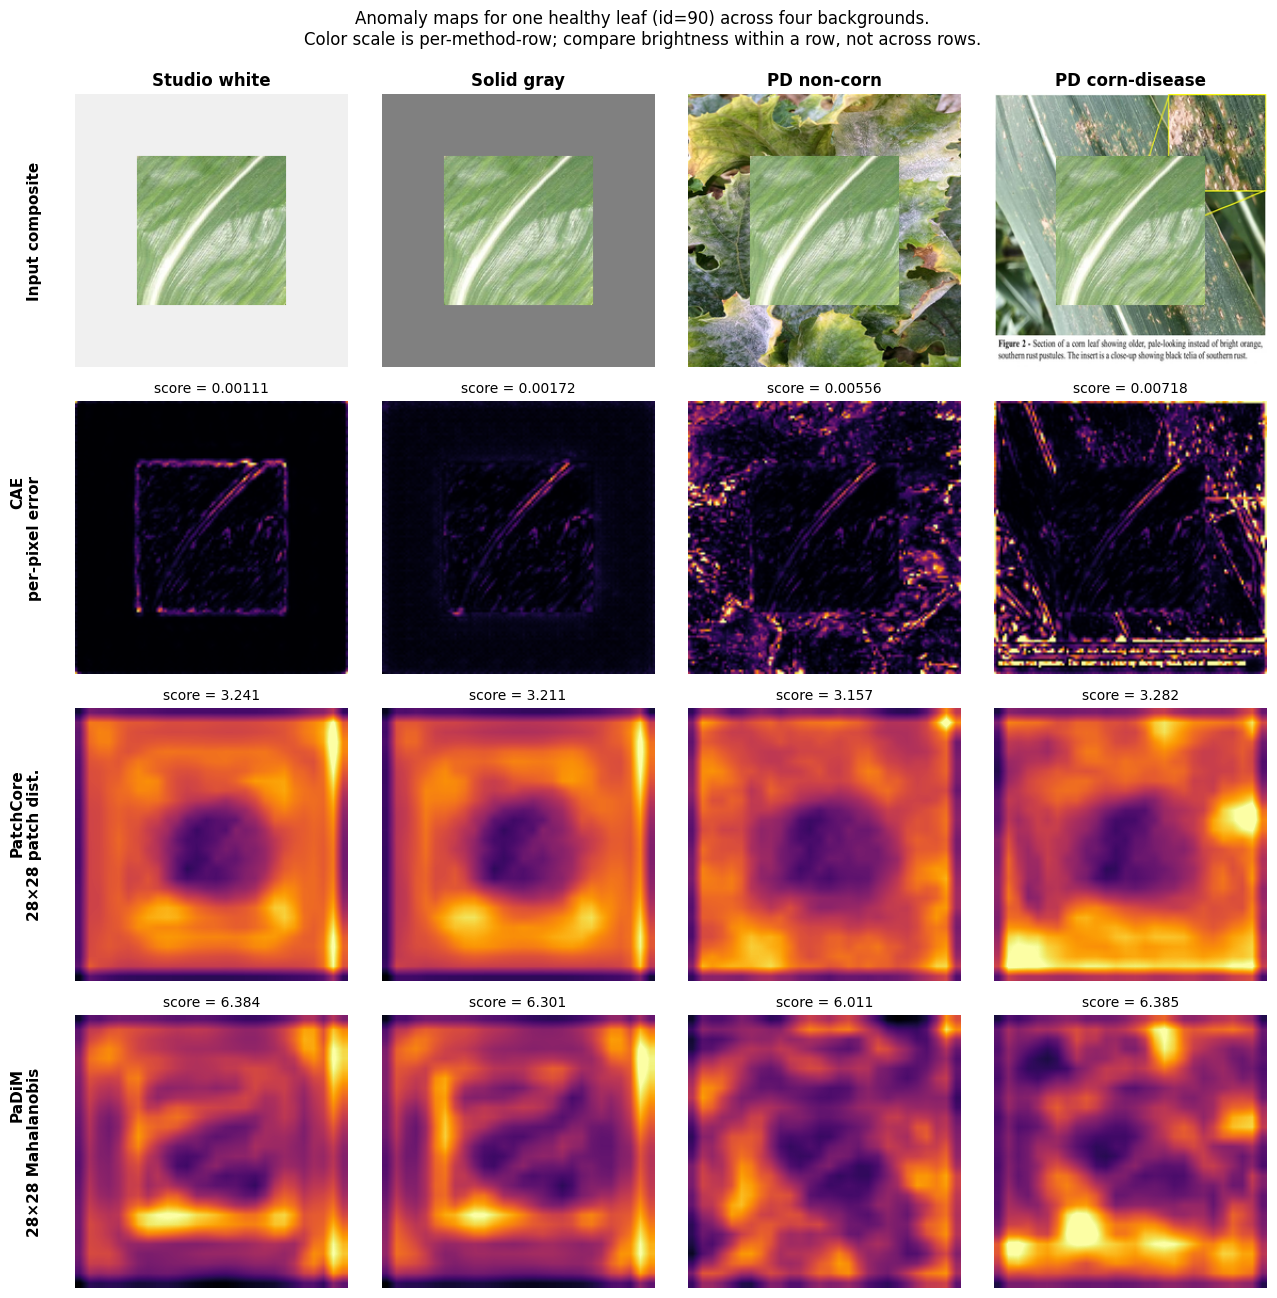


Saved figure: /kaggle/working/nb6_anomaly_maps.png


In [22]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Pick a representative leaf: median PC score on studio_white
pc_studio = bg_scores["studio_white"]["patchcore"]
rep_idx = int(np.argsort(pc_studio)[len(pc_studio) // 2])
print(f"Representative leaf: id={rep_idx}")
print(f"  Path: {stimulus_paths[rep_idx]}")
print(f"  Studio scores: CAE={bg_scores['studio_white']['cae'][rep_idx]:.5f}, "
      f"PC={bg_scores['studio_white']['patchcore'][rep_idx]:.3f}, "
      f"PaDiM={bg_scores['studio_white']['padim'][rep_idx]:.3f}")

panel_composites = {c: composites[c][rep_idx] for c in CONDITIONS}

# Compute anomaly maps for each method x each condition
maps = {"cae": {}, "patchcore": {}, "padim": {}}

with torch.no_grad():
    for cond, img in panel_composites.items():
        # CAE pixel-level
        cae_x   = cae_tfm(img).unsqueeze(0).to(DEVICE)
        cae_rec = cae_model(cae_x)
        maps["cae"][cond] = ((cae_rec - cae_x) ** 2).mean(dim=1).squeeze().cpu().numpy()

        # PatchCore + PaDiM patch-level (28x28)
        pc_x  = pc_tfm(img).unsqueeze(0).to(DEVICE)
        feats = extract_patches(pc_x, backbone, features, flatten=False)
        flat  = feats.reshape(784, 1536)
        maps["patchcore"][cond] = (
            torch.cdist(flat, coreset_bank_gpu).min(dim=1)[0].reshape(28, 28).cpu().numpy()
        )
        sub   = feats[:, :, padim_dim_indices]
        diff  = sub - padim_means.unsqueeze(0)
        mahal = torch.sqrt(torch.einsum('bpi,pij,bpj->bp', diff, padim_inv_covs, diff).clamp(min=0))
        maps["padim"][cond] = mahal.reshape(28, 28).cpu().numpy()

# Within-method color scaling (99th-pct cap to suppress outliers)
vlims = {}
for m in ["cae", "patchcore", "padim"]:
    vals = np.concatenate([maps[m][c].flatten() for c in CONDITIONS])
    vlims[m] = (vals.min(), np.percentile(vals, 99))

COND_TITLES = {
    "studio_white":    "Studio white",
    "solid_gray":      "Solid gray",
    "pd_non_corn":     "PD non-corn",
    "pd_corn_disease": "PD corn-disease",
}
ROW_TITLES = ["Input composite", "CAE\nper-pixel error", "PatchCore\n28×28 patch dist.", "PaDiM\n28×28 Mahalanobis"]

fig, axes = plt.subplots(4, 4, figsize=(13, 13))

for ci, cond in enumerate(CONDITIONS):
    axes[0, ci].imshow(panel_composites[cond])
    axes[0, ci].set_title(COND_TITLES[cond], fontsize=12, fontweight="bold")
    axes[0, ci].axis("off")

    for ri, m in enumerate(["cae", "patchcore", "padim"], start=1):
        im = axes[ri, ci].imshow(maps[m][cond], cmap="inferno",
                                 vmin=vlims[m][0], vmax=vlims[m][1],
                                 interpolation="bilinear")
        score = bg_scores[cond][m][rep_idx]
        fmt   = ".5f" if m == "cae" else ".3f"
        axes[ri, ci].set_title(f"score = {score:{fmt}}", fontsize=10)
        axes[ri, ci].axis("off")

for ri, label in enumerate(ROW_TITLES):
    axes[ri, 0].text(-0.12, 0.5, label, transform=axes[ri, 0].transAxes,
                     fontsize=11, fontweight="bold", rotation=90,
                     ha="right", va="center")

plt.suptitle(f"Anomaly maps for one healthy leaf (id={rep_idx}) across four backgrounds.\n"
             f"Color scale is per-method-row; compare brightness within a row, not across rows.",
             fontsize=12, y=0.995)
plt.tight_layout()

out_fig = Path("/kaggle/working/nb6_anomaly_maps.png")
plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved figure: {out_fig}")

In [23]:
 from scipy import stats

# === Bootstrap 95% CIs on AUROC ===
def bootstrap_auroc(scores_h, scores_d, n_boot=2000, seed=42):
    """Stratified bootstrap: resample healthy and diseased separately."""
    rng = np.random.default_rng(seed)
    n_h, n_d = len(scores_h), len(scores_d)
    boots = []
    for _ in range(n_boot):
        idx_h = rng.integers(0, n_h, n_h)
        idx_d = rng.integers(0, n_d, n_d)
        s = np.concatenate([scores_h[idx_h], scores_d[idx_d]])
        y = np.concatenate([np.zeros(n_h), np.ones(n_d)])
        boots.append(roc_auc_score(y, s))
    return np.percentile(boots, [2.5, 97.5])

print("=== Bootstrap 95% CIs on AUROC (2000 resamples, stratified) ===\n")
print(f"{'Method':<12}  {'In-domain (PV)':>26}  {'Cross-domain (PD)':>26}  {'Unified':>26}")
print("-" * 100)

h_idx = np.where(healthy_mask)[0]
pv_idx = np.where(pv_d_mask)[0]
pd_idx = np.where(pd_d_mask)[0]
all_idx = np.where(all_d_mask)[0]

for name, scores in [("CAE", cae_scores), ("PatchCore", pc_scores), ("PaDiM", padim_scores)]:
    sh = scores[h_idx]
    
    a_in    = roc_auc_score(np.r_[np.zeros(len(h_idx)), np.ones(len(pv_idx))],
                            np.r_[sh, scores[pv_idx]])
    ci_in   = bootstrap_auroc(sh, scores[pv_idx])
    
    a_cross = roc_auc_score(np.r_[np.zeros(len(h_idx)), np.ones(len(pd_idx))],
                            np.r_[sh, scores[pd_idx]])
    ci_cr   = bootstrap_auroc(sh, scores[pd_idx])
    
    a_un    = roc_auc_score(np.r_[np.zeros(len(h_idx)), np.ones(len(all_idx))],
                            np.r_[sh, scores[all_idx]])
    ci_un   = bootstrap_auroc(sh, scores[all_idx])
    
    print(f"{name:<12}  {a_in:.4f} [{ci_in[0]:.4f}, {ci_in[1]:.4f}]  "
          f"{a_cross:.4f} [{ci_cr[0]:.4f}, {ci_cr[1]:.4f}]  "
          f"{a_un:.4f} [{ci_un[0]:.4f}, {ci_un[1]:.4f}]")

# === Paired t-tests on the NB5 100-leaf design ===
print("\n=== Paired t-tests on NB5 (n=100 leaves; studio_white as baseline) ===\n")

for method_key, method_name in [("cae", "CAE"), ("patchcore", "PatchCore"), ("padim", "PaDiM")]:
    print(f"{method_name}:")
    print(f"  {'condition':<18}  {'mean diff':>12}  {'t':>8}  {'p':>10}  {'Cohen d':>9}")
    print(f"  " + "-" * 65)
    base = bg_scores["studio_white"][method_key]
    for cond in ["solid_gray", "pd_non_corn", "pd_corn_disease"]:
        cond_s = bg_scores[cond][method_key]
        diff = cond_s - base
        t, p = stats.ttest_rel(cond_s, base)
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
        print(f"  {cond:<18}  {diff.mean():>+12.5f}  {t:>+8.2f}  {p:>10.2e}  {d:>+9.2f}")
    print()

# === Variance decomposition for PatchCore (within-condition vs across-condition) ===
print("=== PatchCore variance decomposition ===")
print("If the cross-condition movement is just noise, within-condition std should dwarf the cross-condition means.\n")

for method_key, method_name in [("cae", "CAE"), ("patchcore", "PatchCore"), ("padim", "PaDiM")]:
    within_stds = [bg_scores[c][method_key].std(ddof=1) for c in CONDITIONS]
    mean_within_std = np.mean(within_stds)
    cond_means = [bg_scores[c][method_key].mean() for c in CONDITIONS]
    across_std = np.std(cond_means, ddof=1)
    ratio = across_std / mean_within_std
    print(f"{method_name:<10}  mean within-cond std = {mean_within_std:.5f}   "
          f"across-cond mean std = {across_std:.5f}   "
          f"ratio (across/within) = {ratio:.2f}")

=== Bootstrap 95% CIs on AUROC (2000 resamples, stratified) ===

Method                    In-domain (PV)           Cross-domain (PD)                     Unified
----------------------------------------------------------------------------------------------------
CAE           0.9945 [0.9897, 0.9982]  0.9968 [0.9931, 0.9993]  0.9948 [0.9904, 0.9981]
PatchCore     0.9995 [0.9990, 0.9998]  0.9995 [0.9986, 1.0000]  0.9995 [0.9991, 0.9998]
PaDiM         0.9811 [0.9719, 0.9890]  0.9927 [0.9870, 0.9968]  0.9825 [0.9742, 0.9898]

=== Paired t-tests on NB5 (n=100 leaves; studio_white as baseline) ===

CAE:
  condition              mean diff         t           p    Cohen d
  -----------------------------------------------------------------
  solid_gray              +0.00045    +24.33    1.47e-43      +2.43
  pd_non_corn             +0.00407    +11.28    1.82e-19      +1.13
  pd_corn_disease         +0.00336    +17.74    1.65e-32      +1.77

PatchCore:
  condition              mean diff         

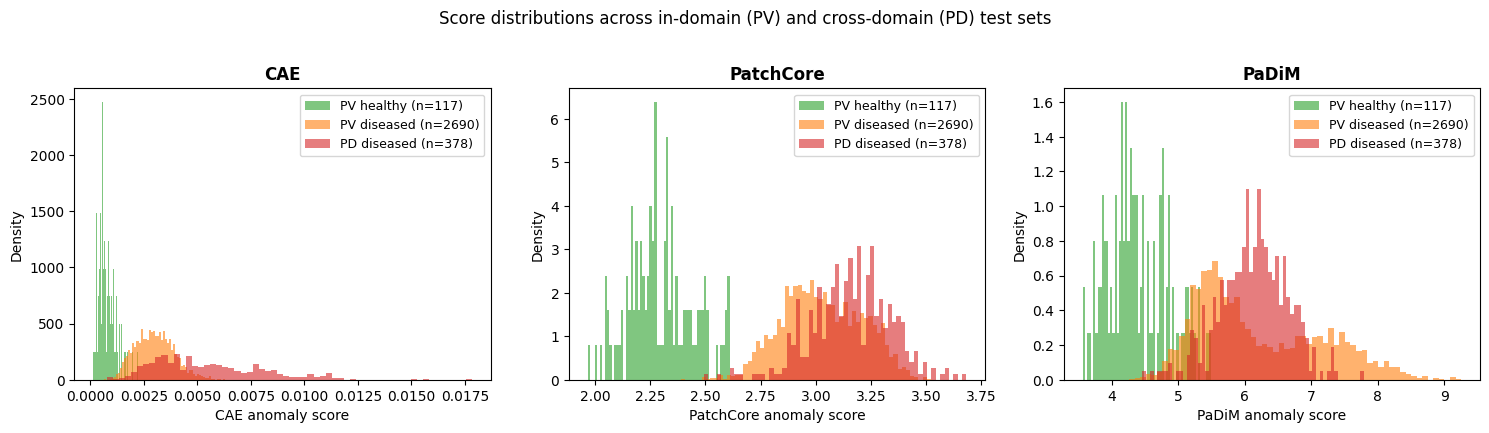

/tmp/ipykernel_57/2297550226.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
/tmp/ipykernel_57/2297550226.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
/tmp/ipykernel_57/2297550226.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,


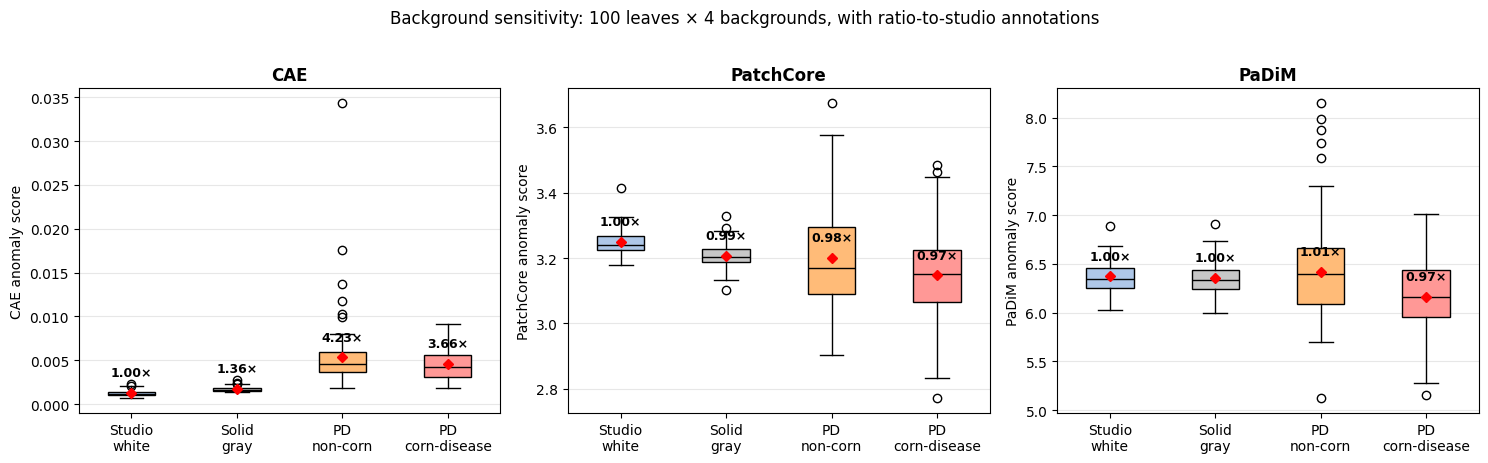


=== All NB6 artifacts saved ===
Directory: /kaggle/working/nb6_artifacts/
  cae_best_nb6.pt                          4240.2 KB
  nb6_anomaly_maps.png                     2079.2 KB
  nb6_background_boxplot.png                111.2 KB
  nb6_background_scores.csv                  83.5 KB
  nb6_score_distributions.png                82.5 KB
  nb6_stats_summary.json                      2.2 KB
  nb6_unified_scores.csv                    665.4 KB

Zipped: /kaggle/working/nb6_artifacts.zip (6.1 MB)


In [24]:
import shutil
import json

OUT = Path("/kaggle/working/nb6_artifacts")
OUT.mkdir(exist_ok=True)

# === Figure: Score distributions per method (paper §4.4) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, scores) in zip(axes, [("CAE", cae_scores),
                                     ("PatchCore", pc_scores),
                                     ("PaDiM", padim_scores)]):
    h_ = scores[healthy_mask]
    pv = scores[pv_d_mask]
    pd_ = scores[pd_d_mask]
    bins = 60
    ax.hist(h_, bins=bins, alpha=0.6, density=True, label=f"PV healthy (n={len(h_)})", color="#2ca02c")
    ax.hist(pv, bins=bins, alpha=0.6, density=True, label=f"PV diseased (n={len(pv)})", color="#ff7f0e")
    ax.hist(pd_, bins=bins, alpha=0.6, density=True, label=f"PD diseased (n={len(pd_)})", color="#d62728")
    ax.set_xlabel(f"{name} anomaly score")
    ax.set_ylabel("Density")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend(loc="best", fontsize=9)
plt.suptitle("Score distributions across in-domain (PV) and cross-domain (PD) test sets",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "nb6_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# === Figure: Background sensitivity boxplot (paper §4.5 secondary) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
COND_LABELS = ["Studio\nwhite", "Solid\ngray", "PD\nnon-corn", "PD\ncorn-disease"]
COLORS = ["#aec7e8", "#c7c7c7", "#ffbb78", "#ff9896"]

for ax, (key, name) in zip(axes, [("cae", "CAE"),
                                   ("patchcore", "PatchCore"),
                                   ("padim", "PaDiM")]):
    data = [bg_scores[c][key] for c in CONDITIONS]
    bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
                    medianprops={"color": "black"},
                    meanprops={"marker": "D", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 5})
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
    base = np.mean(data[0])
    for i, d in enumerate(data):
        r = np.mean(d) / base
        ax.annotate(f"{r:.2f}×", (i + 1, np.mean(d)),
                    textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=9, fontweight="bold")
    ax.set_ylabel(f"{name} anomaly score")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Background sensitivity: 100 leaves × 4 backgrounds, with ratio-to-studio annotations",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "nb6_background_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# === Save existing figures + CSVs + checkpoint into one folder ===
for fname in ["nb6_anomaly_maps.png",
              "nb6_unified_scores.csv",
              "nb6_background_scores.csv"]:
    src = Path(f"/kaggle/working/{fname}")
    if src.exists():
        shutil.copy(src, OUT / fname)

shutil.copy(CAE_CKPT, OUT / "cae_best_nb6.pt")

# === Statistical-results JSON (matches the values you just pasted) ===
stats_summary = {
    "bootstrap_auroc_ci_2000_resamples": {
        "CAE":       {"in_domain": [0.9945, 0.9897, 0.9982],
                      "cross_domain": [0.9968, 0.9931, 0.9993],
                      "unified": [0.9948, 0.9904, 0.9981]},
        "PatchCore": {"in_domain": [0.9995, 0.9990, 0.9998],
                      "cross_domain": [0.9995, 0.9986, 1.0000],
                      "unified": [0.9995, 0.9991, 0.9998]},
        "PaDiM":     {"in_domain": [0.9811, 0.9719, 0.9890],
                      "cross_domain": [0.9927, 0.9870, 0.9968],
                      "unified": [0.9825, 0.9742, 0.9898]},
    },
    "paired_ttest_cohens_d_nb5": {
        "CAE":       {"solid_gray": 2.43, "pd_non_corn": 1.13, "pd_corn_disease": 1.77},
        "PatchCore": {"solid_gray": -2.08, "pd_non_corn": -0.33, "pd_corn_disease": -0.77},
        "PaDiM":     {"solid_gray": -0.29, "pd_non_corn": 0.11, "pd_corn_disease": -0.56},
    },
    "variance_decomposition_nb5": {
        "CAE":       {"within_std": 0.00155, "across_std": 0.00204, "ratio": 1.32},
        "PatchCore": {"within_std": 0.09117, "across_std": 0.04207, "ratio": 0.46},
        "PaDiM":     {"within_std": 0.29651, "across_std": 0.11232, "ratio": 0.38},
    },
    "background_condition_ratios": {
        "CAE":       {"studio_white": 1.00, "solid_gray": 1.36, "pd_non_corn": 4.23, "pd_corn_disease": 3.66},
        "PatchCore": {"studio_white": 1.00, "solid_gray": 0.99, "pd_non_corn": 0.98, "pd_corn_disease": 0.97},
        "PaDiM":     {"studio_white": 1.00, "solid_gray": 1.00, "pd_non_corn": 1.01, "pd_corn_disease": 0.97},
    },
    "score_magnitude_pv_to_pd": {
        "CAE":       {"common_rust": 1.35, "cercospora": 1.90, "northern_blight": 2.46},
        "PatchCore": {"common_rust": 1.00, "cercospora": 1.07, "northern_blight": 1.09},
        "PaDiM":     {"common_rust": 0.85, "cercospora": 1.08, "northern_blight": 1.14},
    },
}
with open(OUT / "nb6_stats_summary.json", "w") as f:
    json.dump(stats_summary, f, indent=2)

# === Zip everything for download ===
zip_path = "/kaggle/working/nb6_artifacts"
shutil.make_archive(zip_path, "zip", OUT)
zip_size_mb = Path(f"{zip_path}.zip").stat().st_size / 1024 / 1024

print(f"\n=== All NB6 artifacts saved ===")
print(f"Directory: {OUT}/")
for f in sorted(OUT.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35}  {size_kb:>10.1f} KB")
print(f"\nZipped: {zip_path}.zip ({zip_size_mb:.1f} MB)")